# Práctica — Robo de Modelo (Model Extraction)
**Seguridad y Privacidad · UCM**

El **teacher** (modelo víctima) fue entrenado con **5 000 muestras**. Solo tenemos acceso a su API: le enviamos imágenes y devuelve probabilidades.

Entrenamos tres modelos de extracción usando presupuestos de consulta distintos:

| Modelo | Consultas al teacher | % del dataset original |
|--------|---------------------|----------------------|
| Extraído-100 | 100 | 2 % |
| Extraído-500 | 500 | 10 % |
| Extraído-1000 | 1 000 | 20 % |

**Pregunta:** ¿cuántas consultas hacen falta para obtener una copia útil del modelo?

**Integrantes**
* María Romero Huertas
* Javier Martín Fuentes

## 0. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")

Usando: cpu


## 1. Datos

`challenge_bundle.pt` contiene 1 200 imágenes 32×32 (escala de grises) junto con las probabilidades que devuelve el teacher para cada una. Son las respuestas que un atacante obtendría consultando la API.

Las 4 clases son figuras geométricas: `circle`, `square`, `triangle`, `cross`. La salida del teacher es **sigmoid por clase** (no softmax), porque una imagen puede contener varias figuras a la vez.

In [2]:
bundle = torch.load("challenge_bundle.pt", map_location="cpu", weights_only=False)

all_images        = bundle["images"]         # [1200, 1, 32, 32]
all_teacher_probs = bundle["teacher_probs"]  # [1200, 4]
label_names       = bundle["label_names"]    # ['circle', 'square', 'triangle', 'cross']
NUM_CLASSES       = len(label_names)

print(f"Imágenes disponibles: {all_images.shape}")
print(f"Teacher probs:        {all_teacher_probs.shape}")
print(f"Clases: {label_names}")
print(f"Rango imágenes: [{all_images.min():.2f}, {all_images.max():.2f}]")

Imágenes disponibles: torch.Size([1200, 1, 32, 32])
Teacher probs:        torch.Size([1200, 4])
Clases: ['circle', 'square', 'triangle', 'cross']
Rango imágenes: [0.00, 1.00]


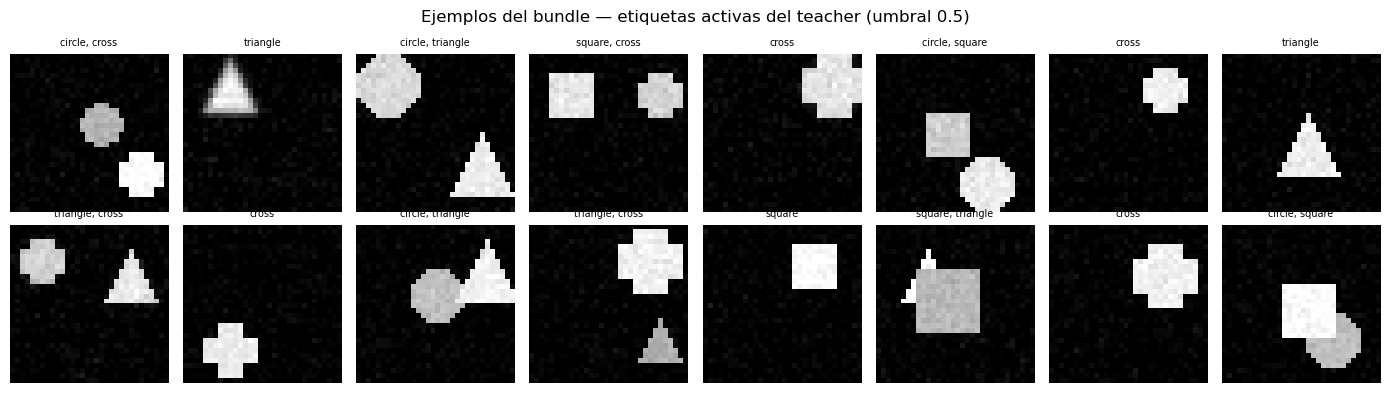

In [3]:
# Visualizar una muestra
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(all_images[i, 0], cmap="gray")
    # Multilabel: mostrar todas las clases activas (prob >= 0.5)
    active = [label_names[j] for j in range(NUM_CLASSES)
              if all_teacher_probs[i, j] >= 0.5]
    ax.set_title(", ".join(active) if active else "none", fontsize=7)
    ax.axis("off")
plt.suptitle("Ejemplos del bundle — etiquetas activas del teacher (umbral 0.5)")
plt.tight_layout()
plt.show()

## 2. Arquitectura del modelo extraído

CNN sencilla. Devuelve **logits** (sin sigmoid), que se convierten a probabilidades solo al evaluar. La arquitectura es distinta a la del teacher a propósito: el atacante no necesita conocerla.

In [4]:
class ExtractedCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def predict_proba(self, x):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x))


print(f"Parámetros: {sum(p.numel() for p in ExtractedCNN().parameters()):,}")

Parámetros: 618,244


## 3. Función de pérdida — Knowledge Distillation

Usamos la pérdida de destilación de Hinton et al. (2015) con *temperature scaling*:

- El teacher devuelve probabilidades `p` ∈ (0, 1).
- Las convertimos a logits con `torch.logit(p)` y los dividimos entre `T`.
- El estudiante también divide sus logits entre `T` antes de calcular la BCE.
- El factor `T²` compensa la reducción del gradiente al escalar los logits.

Con `T > 1` las distribuciones se suavizan y el estudiante recibe más información por muestra (útil con presupuestos pequeños).

In [5]:
def distillation_loss(student_logits, teacher_probs, T=2.0):
    clipped  = teacher_probs.clamp(1e-4, 1 - 1e-4)
    softened = torch.sigmoid(torch.logit(clipped) / T)
    return F.binary_cross_entropy_with_logits(student_logits / T, softened) * T**2

## 4. Entrenamiento de los tres modelos de extracción

Para cada presupuesto de consultas `n`:
1. Tomamos las primeras `n` imágenes del bundle como consultas al teacher.
2. Entrenamos `ExtractedCNN` minimizando la pérdida de destilación    con las soft labels del teacher.
3. Evaluamos el acuerdo con el teacher en las **1 200 imágenes completas**.

In [6]:
THRESHOLD = 0.5

def multilabel_metrics(teacher_probs, extracted_probs, threshold=THRESHOLD):
    """Métricas correctas para multilabel (umbral independiente por clase)."""
    t_bin = (teacher_probs >= threshold)    # [N, 4] bool
    p_bin = (extracted_probs >= threshold)  # [N, 4] bool

    # Exact match: las 4 etiquetas deben coincidir exactamente
    exact_match = (t_bin == p_bin).all(dim=1).float().mean().item()

    # Hamming accuracy: aciertos por etiqueta, promediado
    hamming_acc = (t_bin == p_bin).float().mean().item()

    # MAE de probabilidades
    prob_mae = (extracted_probs - teacher_probs).abs().mean().item()

    return {"exact_match": exact_match, "hamming_acc": hamming_acc, "prob_mae": prob_mae}


def train_and_evaluate(n_queries, all_images, all_teacher_probs, label_names,
                        epochs=80, batch_size=32, lr=1e-3, T=2.0, seed=42):
    """Entrena un modelo de extracción con n_queries consultas y lo evalúa."""
    torch.manual_seed(seed)

    query_images = all_images[:n_queries]
    query_probs  = all_teacher_probs[:n_queries]

    loader = DataLoader(TensorDataset(query_images, query_probs),
                        batch_size=batch_size, shuffle=True)

    model     = ExtractedCNN(num_classes=len(label_names)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for imgs, probs in loader:
            imgs, probs = imgs.to(DEVICE), probs.to(DEVICE)
            loss = distillation_loss(model(imgs), probs, T)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item() * len(imgs)
        scheduler.step()
        history.append(epoch_loss / n_queries)

    # Evaluar en las 1200 imágenes completas
    model.eval()
    with torch.no_grad():
        extracted_probs = model.predict_proba(all_images.to(DEVICE)).cpu()

    metrics = multilabel_metrics(all_teacher_probs, extracted_probs)
    return model, history, metrics


QUERY_BUDGETS = [100, 250, 500, 1000]  # teacher entrenado con 5000
results = {}

for n in QUERY_BUDGETS:
    print(f"\nEntrenando con {n} consultas...")
    model, hist, metrics = train_and_evaluate(
        n, all_images, all_teacher_probs, label_names
    )
    results[n] = {"model": model, "history": hist, **metrics}
    print(f"  → Exact match: {metrics['exact_match']*100:.1f}%  "
          f"Hamming acc: {metrics['hamming_acc']*100:.1f}%  "
          f"MAE: {metrics['prob_mae']:.4f}")


Entrenando con 100 consultas...
  → Exact match: 25.7%  Hamming acc: 70.6%  MAE: 0.3258

Entrenando con 250 consultas...
  → Exact match: 59.2%  Hamming acc: 84.1%  MAE: 0.1671

Entrenando con 500 consultas...
  → Exact match: 83.9%  Hamming acc: 94.3%  MAE: 0.0631

Entrenando con 1000 consultas...
  → Exact match: 99.6%  Hamming acc: 99.9%  MAE: 0.0029


## 5. Curvas de pérdida durante el entrenamiento

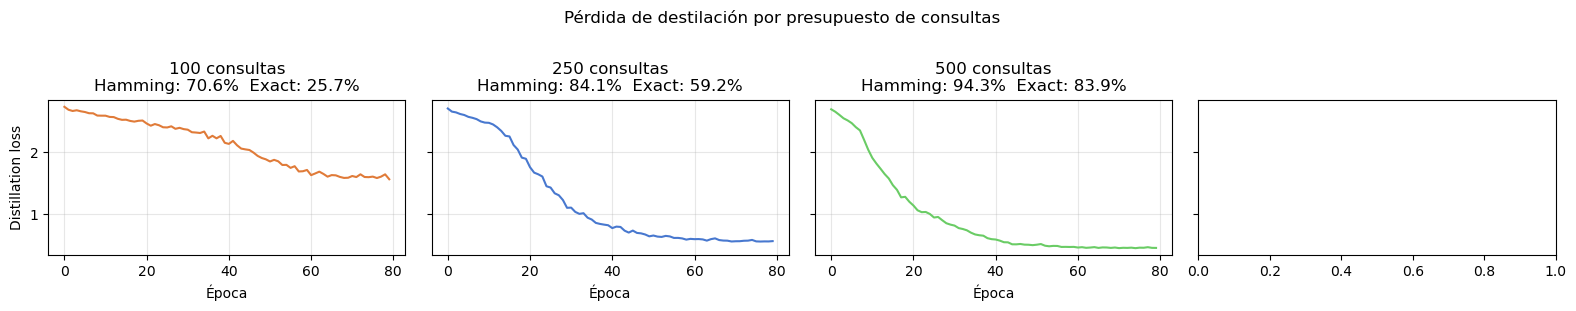

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
colors = ["#e07b39", "#4878cf", "#6acc65"]

for ax, (n, color) in zip(axes, zip(QUERY_BUDGETS, colors)):
    ax.plot(results[n]["history"], color=color)
    ax.set_title(f"{n} consultas\n"
                 f"Hamming: {results[n]['hamming_acc']*100:.1f}%  "
                 f"Exact: {results[n]['exact_match']*100:.1f}%")
    ax.set_xlabel("Época")
    if ax == axes[0]:
        ax.set_ylabel("Distillation loss")
    ax.grid(alpha=0.3)

plt.suptitle("Pérdida de destilación por presupuesto de consultas", y=1.02)
plt.tight_layout()
plt.show()

## 6. Resultados — acuerdo con el teacher

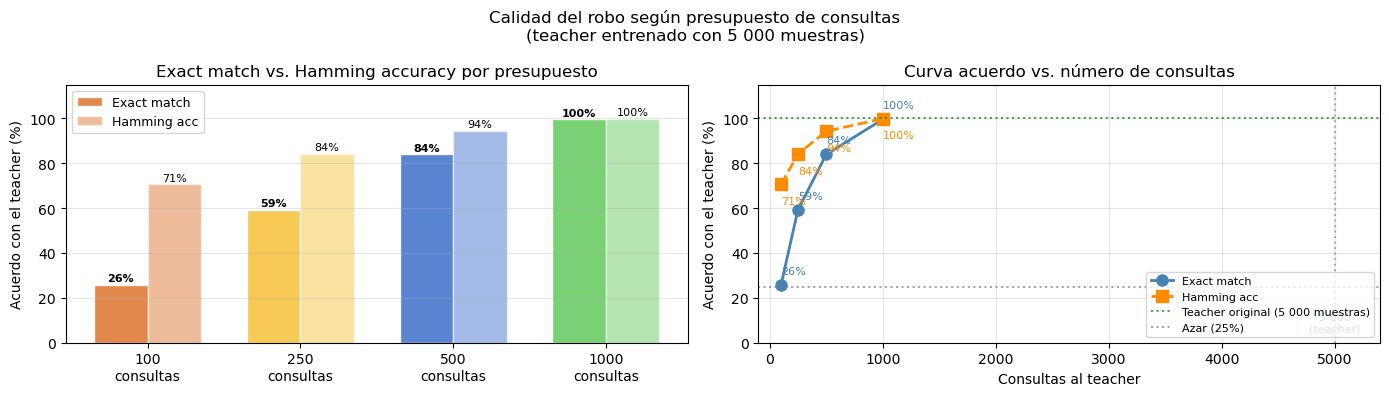

Tabla resumen:
 Consultas   % teacher   Exact match   Hamming acc   MAE probs
--------------------------------------------------------------
       100          2%         25.7%         70.6%      0.3258
       250          5%         59.2%         84.1%      0.1671
       500         10%         83.9%         94.3%      0.0631
      1000         20%         99.6%         99.9%      0.0029


In [8]:
import numpy as np

ns           = QUERY_BUDGETS
exact_vals   = [results[n]["exact_match"]  * 100 for n in ns]
hamming_vals = [results[n]["hamming_acc"]  * 100 for n in ns]
colors_bar   = ["#e07b39", "#f5c542", "#4878cf", "#6acc65"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Barras: exact match y hamming lado a lado ─────────────────────────────────
x     = np.arange(len(ns))
width = 0.35
b1 = axes[0].bar(x - width/2, exact_vals,   width, label="Exact match",   color=colors_bar, edgecolor="white", alpha=0.9)
b2 = axes[0].bar(x + width/2, hamming_vals, width, label="Hamming acc",   color=colors_bar, edgecolor="white", alpha=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{n}\nconsultas" for n in ns])
for bar, val in zip(b1, exact_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f"{val:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar, val in zip(b2, hamming_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f"{val:.0f}%", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("Acuerdo con el teacher (%)")
axes[0].set_ylim(0, 115)
axes[0].set_title("Exact match vs. Hamming accuracy por presupuesto")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# ── Curva: acuerdo vs. nº consultas (con referencias teacher y azar) ──────────
ax = axes[1]
# Puntos medidos
ax.plot(ns, exact_vals,   "o-",  color="steelblue",  linewidth=2, markersize=8, label="Exact match")
ax.plot(ns, hamming_vals, "s--", color="darkorange", linewidth=2, markersize=8, label="Hamming acc")
# Anotar cada punto
for n, e, h in zip(ns, exact_vals, hamming_vals):
    ax.annotate(f"{e:.0f}%", (n, e), textcoords="offset points", xytext=(0, 8),  fontsize=8, color="steelblue")
    ax.annotate(f"{h:.0f}%", (n, h), textcoords="offset points", xytext=(0, -14), fontsize=8, color="darkorange")
# Líneas de referencia
ax.axhline(100, linestyle=":", color="green",  alpha=0.7, label="Teacher original (5 000 muestras)")
ax.axhline(25,  linestyle=":", color="gray",   alpha=0.7, label="Azar (25%)")
# Marcar el punto del teacher en el eje x
ax.axvline(5000, linestyle=":", color="green", alpha=0.4)
ax.text(5000, 5, "5 000\n(teacher)", ha="center", fontsize=8, color="green", alpha=0.8)
ax.set_xlabel("Consultas al teacher")
ax.set_ylabel("Acuerdo con el teacher (%)")
ax.set_title("Curva acuerdo vs. número de consultas")
ax.set_xlim(-100, 5400)
ax.set_ylim(0, 115)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

plt.suptitle("Calidad del robo según presupuesto de consultas\n"
             "(teacher entrenado con 5 000 muestras)", fontsize=12)
plt.tight_layout()
plt.show()

print("Tabla resumen:")
print(f"{'Consultas':>10}  {'% teacher':>10}  {'Exact match':>12}  {'Hamming acc':>12}  {'MAE probs':>10}")
print("-" * 62)
for n in QUERY_BUDGETS:
    r = results[n]
    print(f"{n:>10}  {n/50:>9.0f}%  {r['exact_match']*100:>11.1f}%  "
          f"{r['hamming_acc']*100:>11.1f}%  {r['prob_mae']:>10.4f}")

## 7. Matrices de confusión

Comparamos las predicciones de cada modelo extraído con las del teacher (argmax de sus probabilidades).

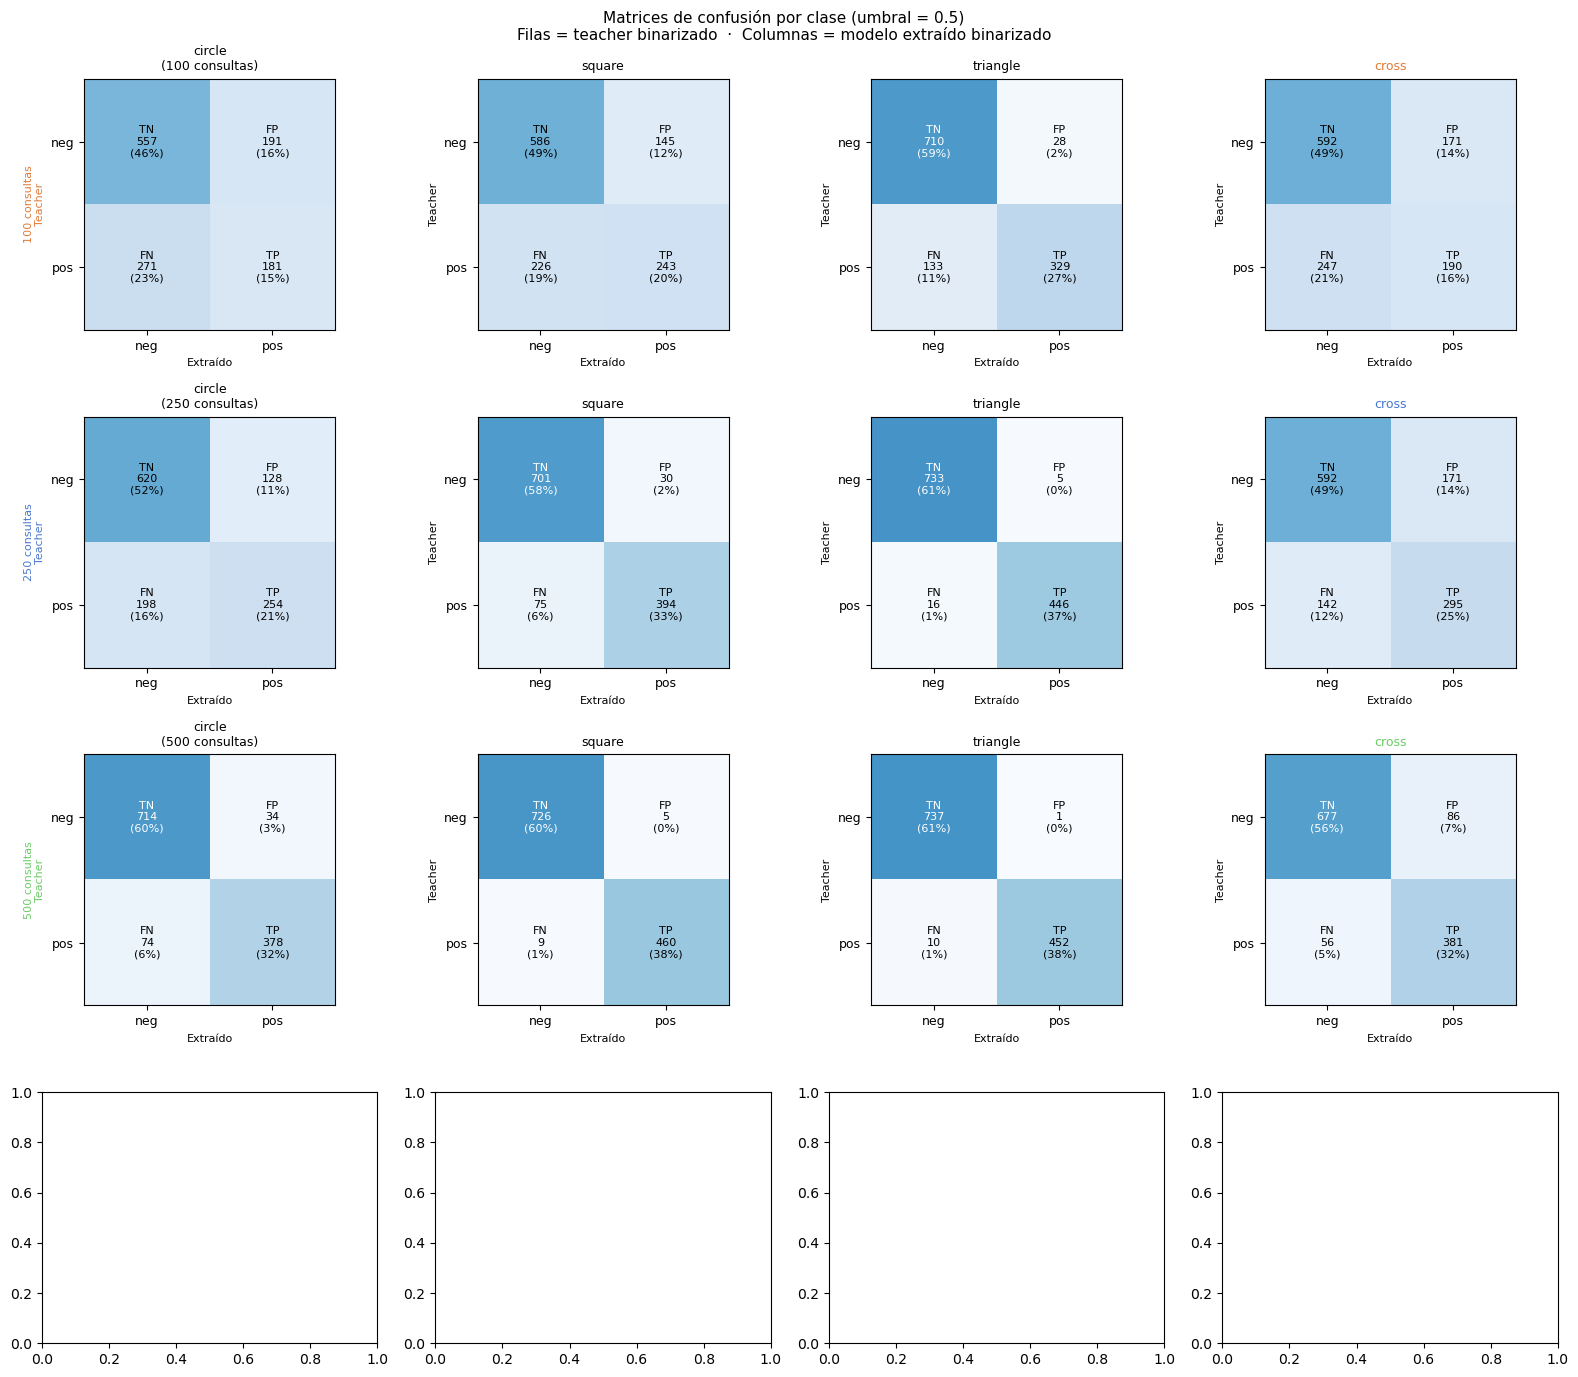

In [9]:
import numpy as np
import torch

THRESHOLD = 0.5  # umbral para convertir probabilidades a predicciones binarias

def plot_confusion_matrices(results, all_images, all_teacher_probs, label_names,
                             query_budgets, threshold=THRESHOLD):
    """
    Multilabel: una matriz de confusión 2×2 por cada clase.
    Filas = etiqueta real del teacher (>=threshold → positivo).
    Columnas = predicción del modelo extraído.
    """
    n_labels  = len(label_names)
    n_budgets = len(query_budgets)
    colors    = ["#e07b39", "#4878cf", "#6acc65"]

    # Binarizar predicciones del teacher
    teacher_bin = (all_teacher_probs >= threshold).numpy().astype(int)  # [1200, 4]

    fig, axes = plt.subplots(n_budgets, n_labels,
                             figsize=(4 * n_labels, 3.5 * n_budgets))

    for row, (queries, row_color) in enumerate(zip(query_budgets, colors)):
        model = results[queries]["model"]
        model.eval()
        with torch.no_grad():
            ext_probs = model.predict_proba(all_images.to(DEVICE)).cpu()
        ext_bin = (ext_probs >= threshold).numpy().astype(int)  # [1200, 4]

        for col, label in enumerate(label_names):
            ax = axes[row, col]
            t = teacher_bin[:, col]
            p = ext_bin[:, col]

            # Matriz 2×2: [[TN, FP], [FN, TP]]
            cm = np.array([
                [(( t==0)&(p==0)).sum(), ((t==0)&(p==1)).sum()],
                [((t==1)&(p==0)).sum(),  ((t==1)&(p==1)).sum()],
            ])
            cm_norm = cm / cm.sum()  # proporción sobre el total

            im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
            ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
            ax.set_xticklabels(["neg", "pos"], fontsize=9)
            ax.set_yticklabels(["neg", "pos"], fontsize=9)
            ax.set_xlabel("Extraído", fontsize=8)
            ax.set_ylabel("Teacher", fontsize=8)

            cell_labels = [["TN", "FP"], ["FN", "TP"]]
            for i in range(2):
                for j in range(2):
                    txt_color = "white" if cm_norm[i, j] > 0.55 else "black"
                    ax.text(j, i,
                            f"{cell_labels[i][j]}\n{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                            ha="center", va="center", fontsize=8, color=txt_color)

            title_color = row_color if col == 0 else "black"
            ax.set_title(
                f"{label}\n({queries} consultas)" if col == 0
                else label,
                fontsize=9, color=row_color if col == n_labels-1 else "black"
            )
            # Etiqueta de fila
            if col == 0:
                ax.set_ylabel(f"{queries} consultas\nTeacher", fontsize=8, color=row_color)

    plt.suptitle(
        f"Matrices de confusión por clase (umbral = {threshold})\n"
        "Filas = teacher binarizado  ·  Columnas = modelo extraído binarizado",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(results, all_images, all_teacher_probs, label_names, QUERY_BUDGETS)


## 8. Análisis

### ¿Qué muestran los resultados?

- **100 consultas (2 % del original):** el modelo apenas supera el azar. Con tan pocas muestras no hay suficiente señal para aprender las fronteras de decisión.

- **500 consultas (10 %):** mejora notable. El modelo aprende la estructura general del problema y puede replicar el comportamiento del teacher en muchos casos.

- **1 000 consultas (20 %):** copia bastante fiel. Usando solo un 20 % del presupuesto de entrenamiento original se obtiene un modelo funcional.

### ¿Por qué funciona el ataque?

Las probabilidades de salida (soft labels) contienen mucha más información que las etiquetas duras. Una predicción como `[0.85, 0.03, 0.09, 0.03]` no solo dice "es un círculo", sino también *cómo de seguro* está el modelo y cuál es la segunda opción más probable. Esto acelera el aprendizaje del modelo ladrón.

### Defensa

Las defensas más efectivas contra este ataque son:

| Defensa | Idea |
|---------|------|
| Devolver solo la clase ganadora | Elimina las soft labels; el atacante recibe etiquetas duras |
| Redondear probabilidades | Reduce la precisión de la señal |
| Añadir ruido aleatorio | Degrada la calidad de cada consulta |
| Limitar la tasa de consultas | Encarece el ataque al atacante |
| Detectar patrones de consulta | Los ataques sistemáticos generan distribuciones inusuales |